In [2]:
# Esse código é apenas para não aparecer avisos de Warnings quando formos treinar o modelo
import os

os.environ["OMP_NUM_THREADS"] = "1"

In [3]:
import pandas as pd

DATA = "../data/Mall_Customers_no_CustomerID.csv"

df = pd.read_csv(DATA)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [7]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Estamos fazendo o pre_processamento para ajustarmos todas as colunas para a mesma escala
# O standardscaler é utilizado para colunas númericas, enquanto o onehotencoder para colunas de texto
preprocessing = ColumnTransformer(
    [
        ("standard", StandardScaler(), ["Age", "Annual Income (k$)", "Spending Score (1-100)"]),
        ("onehot", OneHotEncoder(), ["Gender"])
    ]
)

#Aplicando o pre-processamento de fato
preprocessing.fit_transform(df)

df_scaled = pd.DataFrame(
    preprocessing.fit_transform(df),
    columns=preprocessing.get_feature_names_out(),
)

df_scaled.head()

,standard__Age,standard__Annual Income (k$),standard__Spending Score (1-100),onehot__Gender_Female,onehot__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


In [5]:
df_scaled.to_csv("../data/Mall_Customers_no_CustomerID_scaled.csv", index=False)

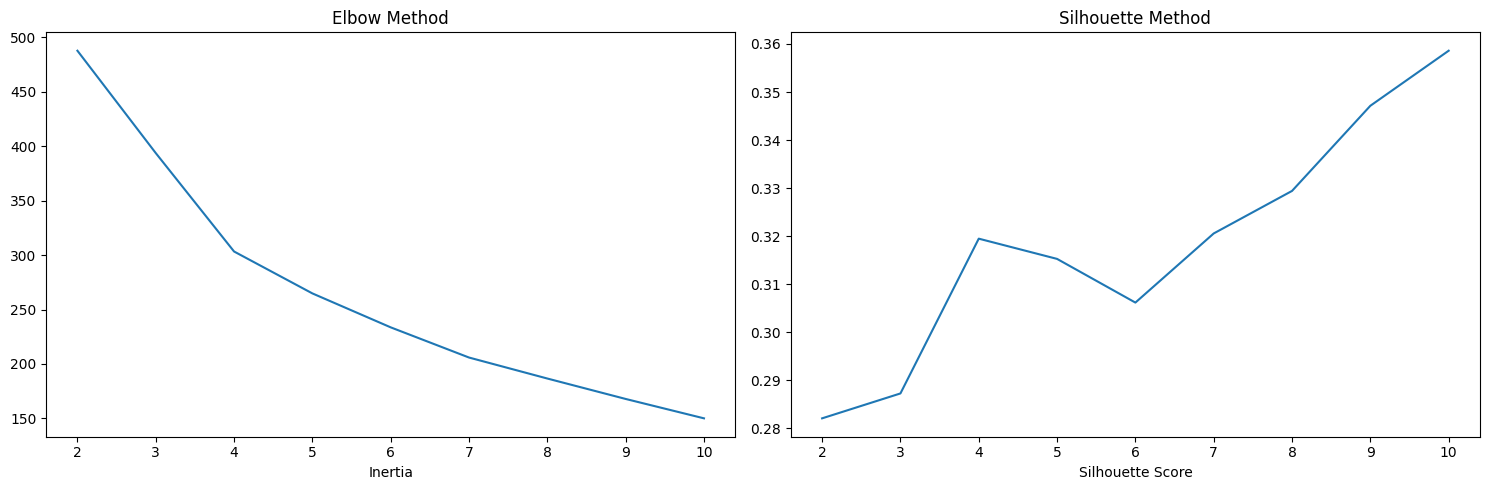

In [6]:
from funcoes_auxiliares import graficos_elbow_silhouette

graficos_elbow_silhouette(df_scaled)

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

pipeline = Pipeline(
    [
        ("preprocessing", preprocessing), 
        ("clustering", KMeans(n_clusters=4, random_state=42, n_init=10))
    ]
)

pipeline.fit(df)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standard', StandardScaler(),
                                                  ['Age', 'Annual Income (k$)',
                                                   'Spending Score (1-100)']),
                                                 ('onehot', OneHotEncoder(),
                                                  ['Gender'])])),
                ('clustering',
                 KMeans(n_clusters=4, n_init=10, random_state=42))])

In [21]:
pipeline["clustering"].labels_

array([2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2,
       2, 0, 0, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 0,
       0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 3, 1, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

In [22]:
df_clustered = df.copy()
df_clustered["cluster"] = pipeline["clustering"].labels_

df_clustered.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,Male,19,15,39,2
1,Male,21,15,81,2
2,Female,20,16,6,2
3,Female,23,16,77,2
4,Female,31,17,40,2


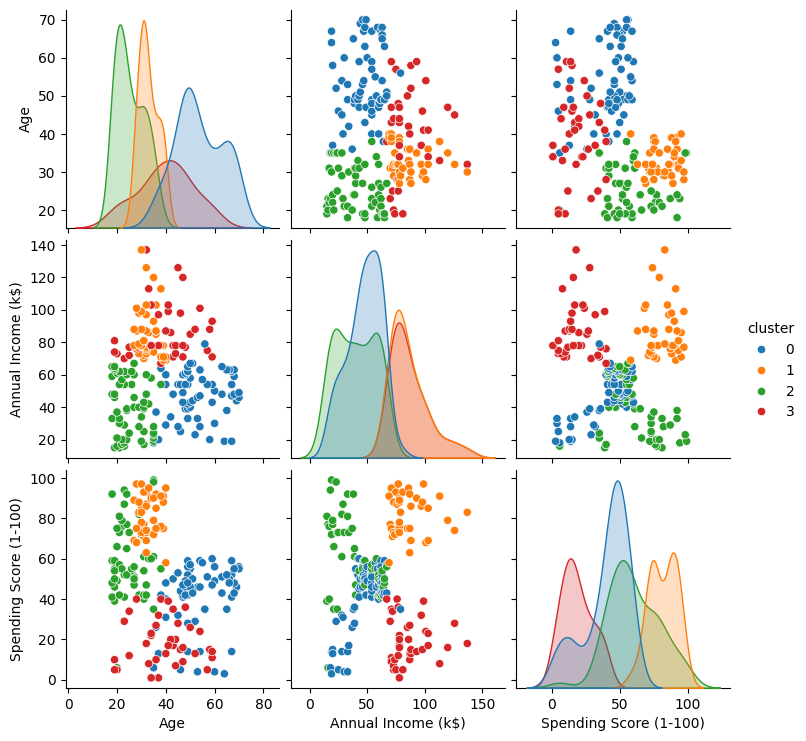

In [23]:
import seaborn as sns

# diag_kind="kde", serve para criar um histograma ao invés de um gráfico de barrar, o que ajuda na visualização
sns.pairplot(df_clustered, diag_kind="kde", hue="cluster", palette="tab10");

Isso é muito mágico, nesse caso fica claro que temos que focar nas pessoas que são do cluster 1 e 2, agora vamos entender quais são as características ddesses clusters

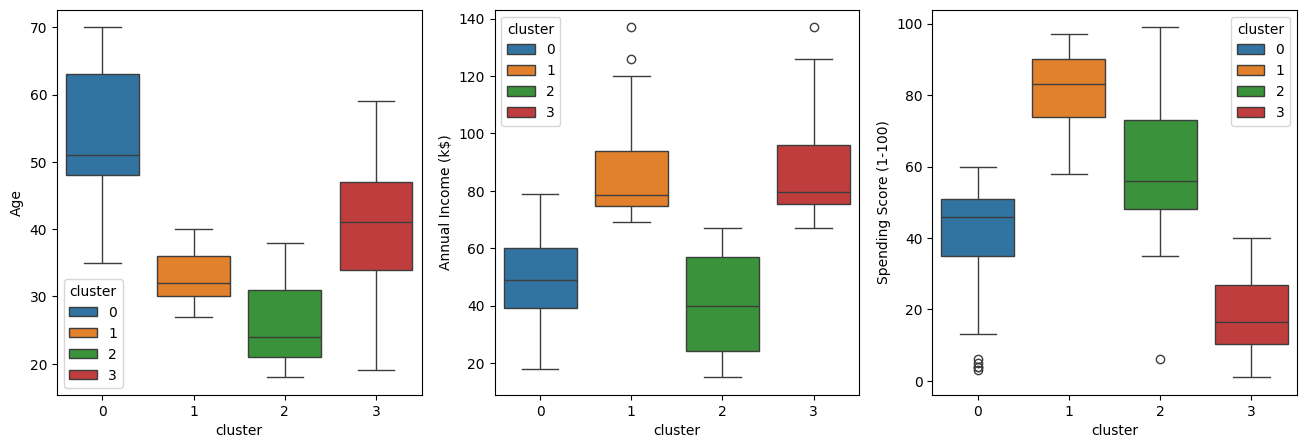

In [32]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

for ax, col in zip(axs, df_clustered.select_dtypes("number")):
    sns.boxplot(data=df_clustered, x="cluster", y=col, ax=ax, hue="cluster", palette="tab10")

plt.show()

Podemos traçar alguns perfis, lembrando que os que tem maior score são 1 e 2:

0 - Pessoas com mais de 50 anos, baixa renda e spending score médio
1 - Adultos entre 30 e 40 anos, alta renda e alto spending score
2 - Jovens de 20 e 30 anos, baixa renda, alto spending score
3 - Idade mesclada, maior parte de 35 até 50 anos, alta renda, baixo spending score.

Dessa forma, se quisermos cativar essas pessoas com alto spending score a gastarem, precisamos focar em adultos entre 30 e 40 anos de alta renda e jovens de 20 a 30 anos de baixa renda, públicos bem distintos. 

In [29]:
df_clustered["cluster"].value_counts().sort_index()

cluster
0    65
1    40
2    57
3    38
Name: count, dtype: int64

In [30]:
df_clustered.groupby(["cluster", "Gender"]).size()

cluster  Gender
0        Female    38
         Male      27
1        Female    22
         Male      18
2        Female    34
         Male      23
3        Female    18
         Male      20
dtype: int64

Com mais essa análise podemos ver que os clusters que gostariamos de focar tem um número maior de mulheres do que homens.

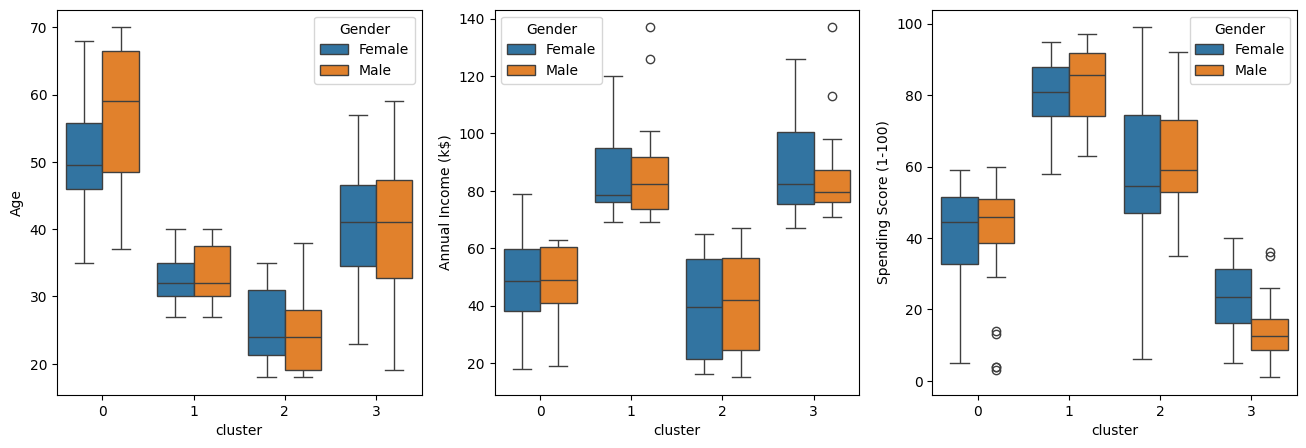

In [34]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

for ax, col in zip(axs, df_clustered.select_dtypes("number")):
    sns.boxplot(data=df_clustered, x="cluster", y=col, ax=ax, hue="Gender", palette="tab10")

plt.show()

In [35]:
pipeline["preprocessing"].get_feature_names_out()

array(['standard__Age', 'standard__Annual Income (k$)',
       'standard__Spending Score (1-100)', 'onehot__Gender_Female',
       'onehot__Gender_Male'], dtype=object)

In [36]:
pipeline["clustering"].cluster_centers_

array([[ 1.06297508, -0.4946758 , -0.37865953,  0.58461538,  0.41538462],
       [-0.42880597,  0.97484722,  1.21608539,  0.55      ,  0.45      ],
       [-0.96249203, -0.78476346,  0.39202966,  0.59649123,  0.40350877],
       [ 0.0768659 ,  0.9971462 , -1.22042727,  0.47368421,  0.52631579]])

In [37]:
pipeline["clustering"].cluster_centers_[:, :-2]

array([[ 1.06297508, -0.4946758 , -0.37865953],
       [-0.42880597,  0.97484722,  1.21608539],
       [-0.96249203, -0.78476346,  0.39202966],
       [ 0.0768659 ,  0.9971462 , -1.22042727]])

In [40]:
centroids=pipeline["clustering"].cluster_centers_[:, :-2]

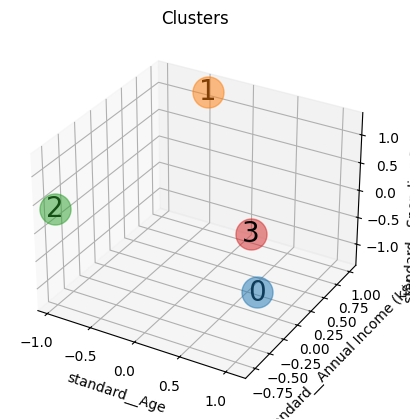

In [41]:
from funcoes_auxiliares import visualizar_clusters

visualizar_clusters(
    dataframe=df_scaled,
    colunas=['standard__Age', 'standard__Annual Income (k$)', 'standard__Spending Score (1-100)'],
    quantidade_cores=5,
    centroids=centroids,
)

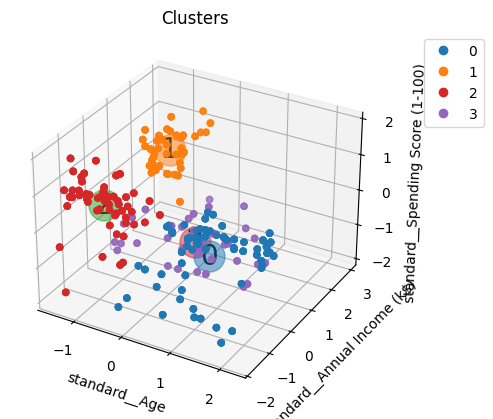

In [43]:
visualizar_clusters(
    dataframe=df_scaled,
    colunas=['standard__Age', 'standard__Annual Income (k$)', 'standard__Spending Score (1-100)'],
    quantidade_cores=5,
    centroids=centroids,
    mostrar_pontos=True,
    coluna_clusters=df_clustered["cluster"]
)